# Задача 9. Hand-crafted graph features

* **Дедлайн**: 16.05.2025, 23:59
* Основной полный балл: 5
* Максимум баллов: 10


## Задача

- [x] Найти или сгенерировать набор данных для бинарной классификации графов.
- [x] Реализовать функцию `shortest_path_kernel(train_graphs, test_graphs)`, которая принимает тренировочный и тестовые наборы, а возвращает пару `K_train, K_test`
  - Опишите графы с помощью вектора из количества кратчайших путей различной длины
  - Для вычисления длин кратчайших путей можно использовать `nx.shortest_path_length(G)`
  - Ядровая функция для сравнения двух графов - скалярное произведение их двух векторов
  - `K_train` - матрица из ядровых функций для сравнения тренировочных графов между собой
  - `K_test` - матрица из ядровых функций для сравнения тестовых графов с тренировочными
- [x] Используя реализованное ядро обучите модель SVC, подберите гиперпараметры, вычислите различные метрики качества
- [x] (+5 баллов) Также реализовать Weisfeiler-Lehman Kernel и обучить классификатор с ним, сравнить результаты.


In [83]:
import networkx as nx
import numpy as np
from collections import defaultdict
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin

rng = np.random.default_rng(42)

In [41]:
def generate_graph_with_bridge(max_n_nodes):
    """Генерирует граф с минимум одним мостом."""
    if np.random.rand() > 0.5:
        bridge_len = rng.integers(0, 3)
        n = rng.integers(2, (max_n_nodes - bridge_len) // 2)
        G = nx.barbell_graph(n, bridge_len)
    else:
        G = nx.path_graph(rng.integers(2, max_n_nodes))
    return G

def generate_graph_without_bridge(max_n_nodes):
    """Генерирует граф без мостов."""
    # Вариант 1: Полный граф
    if np.random.rand() > 0.5:
        G = nx.complete_graph(rng.integers(2, max_n_nodes))
    # Вариант 2: Цикл + случайные рёбра
    else:
        n_to_add = rng.integers(1, max_n_nodes // 2)
        n = rng.integers(3, max_n_nodes - n_to_add)
        G = nx.cycle_graph(n)
        for _ in range(n_to_add):
            u, v = rng.choice(n, 2, replace=False)
            G.add_edge(u, v)
    return G

def generate_bridge_dataset(n_samples=200, max_nodes=30):
    """Создаёт датасет с графами (с мостами и без)."""
    graphs = []
    labels = []
    
    for _ in range(n_samples // 2):
        # Класс 1: Граф с мостом
        G = generate_graph_with_bridge(max_nodes)
        graphs.append(G)
        labels.append(1)
        
        # Класс 0: Граф без мостов
        G = generate_graph_without_bridge(max_nodes)
        graphs.append(G)
        labels.append(0)
    
    return graphs, np.array(labels)


graphs, y = generate_bridge_dataset(n_samples=10000)
X_train, X_test, y_train, y_test = train_test_split(graphs, y, test_size=0.3, random_state=42)

1


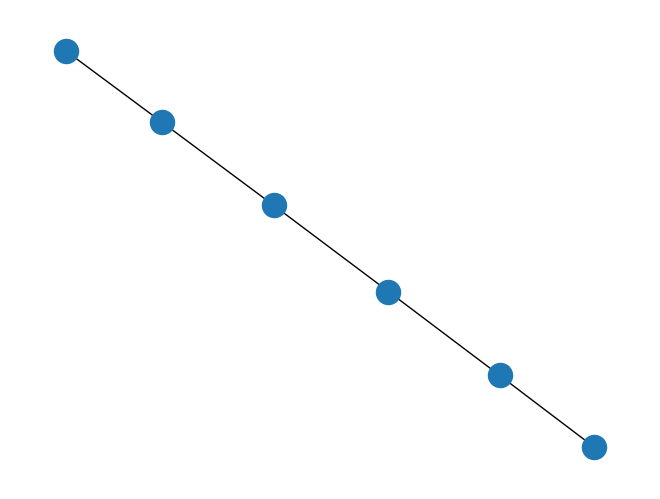

In [79]:
n = 1023

nx.draw(X_train[n])
print(y_train[n])

In [42]:
def shortest_path_kernel(train_graphs, test_graphs, max_path_length=5):
    """
    Вычисляет ядровые матрицы для train и test графов на основе кратчайших путей
    
    Параметры:
    train_graphs - список тренировочных графов (NetworkX)
    test_graphs - список тестовых графов (NetworkX)
    max_path_length - максимальная длина пути для учета в векторе признаков
    
    Возвращает:
    K_train - матрица ядра (n_train x n_train)
    K_test - матрица ядра (n_test x n_train)
    """
    # Сначала вычисляем векторы для всех графов
    def compute_path_vector(G):
        # Инициализируем вектор подсчета путей
        path_counts = np.zeros(max_path_length)
        
        # Вычисляем все кратчайшие пути
        lengths = dict(nx.shortest_path_length(G))
        
        # Подсчитываем длины путей между всеми парами узлов
        for source in lengths:
            for target in lengths[source]:
                if source != target:
                    length = lengths[source][target]
                    if length <= max_path_length:
                        path_counts[length-1] += 1
        
        # Нормализуем по количеству возможных пар узлов
        n_nodes = G.number_of_nodes()
        if n_nodes > 1:
            path_counts /= (n_nodes * (n_nodes - 1))
        
        return path_counts
    
    # Вычисляем векторы для тренировочных графов
    train_vectors = np.array([compute_path_vector(G) for G in train_graphs])
    
    # Вычисляем матрицу ядра для тренировочных данных
    K_train = np.dot(train_vectors, train_vectors.T)
    
    # Вычисляем векторы для тестовых графов (если они предоставлены)
    if test_graphs is not None:
        test_vectors = np.array([compute_path_vector(G) for G in test_graphs])
        # Вычисляем матрицу ядра между тестовыми и тренировочными данными
        K_test = np.dot(test_vectors, train_vectors.T)
    else:
        K_test = None
    
    return K_train, K_test

In [81]:
# Вычисляем ядровые матрицы
K_train, K_test = shortest_path_kernel(X_train, X_test, max_path_length=15)

# Обучение SVM с подбором гиперпараметров
parameters = {'C': [0.001, 0.1, 10, 100, 1000], 'gamma': ['scale', 'auto']}
svc = SVC(kernel='precomputed', random_state=42)
clf = GridSearchCV(svc, parameters, cv=10, n_jobs=8)
clf.fit(K_train, y_train)

# Лучшие параметры
print(f"Лучшие параметры: {clf.best_params_}")

# Предсказание на тестовых данных
y_pred = clf.predict(K_test)

# Оценка качества
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"F1-score: {f1:.3f}")
print("Confusion matrix:")
print(conf_matrix)

Лучшие параметры: {'C': 0.1, 'gamma': 'scale'}
Accuracy: 0.841
F1-score: 0.853
Confusion matrix:
[[1142  358]
 [ 118 1382]]


In [84]:
class WeisfeilerLehmanKernel(BaseEstimator, TransformerMixin):
    def __init__(self, n_iter=3, normalize=True):
        self.n_iter = n_iter          # Количество итераций WL
        self.normalize = normalize    # Нормализация ядра
        self.label_dict = {}          # Словарь для хранения меток
        self._train_graphs = None     # Тренировочные графы

    def _wl_iteration(self, graph, labels):
        """Одна итерация алгоритма Вайсфейлера-Лемана."""
        new_labels = {}
        for node in graph.nodes():
            # Собираем метки соседей и сортируем их
            neighbor_labels = [labels[neighbor] for neighbor in graph.neighbors(node)]
            neighbor_labels = tuple(sorted(neighbor_labels))
            # Новая метка = текущая метка + метки соседей
            new_label = (labels[node], neighbor_labels)
            # Хэшируем в уникальный идентификатор
            if new_label not in self.label_dict:
                self.label_dict[new_label] = len(self.label_dict) + 1
            new_labels[node] = self.label_dict[new_label]
        return new_labels

    def _compute_wl_vector(self, graph):
        """Вычисляет вектор признаков для графа после n_iter итераций."""
        labels = {node: 1 for node in graph.nodes()}  # Начальные метки
        feature_vector = defaultdict(int)
        
        # Сохраняем начальное распределение меток
        for label in labels.values():
            feature_vector[label] += 1
        
        # Итерации WL
        for _ in range(self.n_iter):
            labels = self._wl_iteration(graph, labels)
            for label in labels.values():
                feature_vector[label] += 1
        
        return feature_vector

    def fit(self, graphs, y=None):
        """Сохраняет тренировочные графы и строит словарь меток."""
        self._train_graphs = graphs
        self.label_dict = {}  # Сброс словаря меток
        
        # Проходим по всем графам, чтобы собрать все возможные метки
        for G in graphs:
            self._compute_wl_vector(G)
        return self

    def transform(self, graphs):
        """Преобразует графы в матрицу признаков."""
        n_train = len(self._train_graphs)
        n_test = len(graphs)
        K = np.zeros((n_test, n_train))
        
        # Вычисляем векторы для тестовых графов
        test_vectors = [self._compute_wl_vector(G) for G in graphs]
        
        # Вычисляем векторы для тренировочных графов
        train_vectors = [self._compute_wl_vector(G) for G in self._train_graphs]
        
        # Вычисляем ядровую матрицу (скалярное произведение векторов)
        for i in range(n_test):
            for j in range(n_train):
                # Общие метки между графами i и j
                common_labels = set(test_vectors[i].keys()) & set(train_vectors[j].keys())
                kernel_value = sum(test_vectors[i][k] * train_vectors[j][k] for k in common_labels)
                if self.normalize:
                    norm_i = np.sqrt(sum(v ** 2 for v in test_vectors[i].values()))
                    norm_j = np.sqrt(sum(v ** 2 for v in train_vectors[j].values()))
                    kernel_value /= (norm_i * norm_j + 1e-8)
                K[i, j] = kernel_value
        return K

In [85]:
# Вычисляем WLK
wl_kernel = WeisfeilerLehmanKernel(n_iter=3)
wl_kernel.fit(X_train)
K_train_wl = wl_kernel.transform(X_train)
K_test_wl = wl_kernel.transform(X_test)

# Обучаем SVM на WLK
svc_wl = SVC(kernel='precomputed', random_state=42)
clf_wl = GridSearchCV(svc_wl, parameters, cv=10, n_jobs=8)
clf_wl.fit(K_train_wl, y_train)

# Предсказание и оценка
y_pred_wl = clf_wl.predict(K_test_wl)
accuracy_wl = accuracy_score(y_test, y_pred_wl)
f1_wl = f1_score(y_test, y_pred_wl)

print("\nWeisfeiler-Lehman Kernel Results:")
print(f"Лучшие параметры: {clf_wl.best_params_}")
print(f"Accuracy: {accuracy_wl:.3f}")
print(f"F1-score: {f1_wl:.3f}")

# Сравнение с Shortest Path Kernel
print("\nСравнение методов:")
print(f"Shortest Path Kernel | Accuracy: {accuracy:.3f} | F1: {f1:.3f}")
print(f"Weisfeiler-Lehman    | Accuracy: {accuracy_wl:.3f} | F1: {f1_wl:.3f}")


Weisfeiler-Lehman Kernel Results:
Лучшие параметры: {'C': 10, 'gamma': 'scale'}
Accuracy: 0.990
F1-score: 0.990

Сравнение методов:
Shortest Path Kernel | Accuracy: 0.841 | F1: 0.853
Weisfeiler-Lehman    | Accuracy: 0.990 | F1: 0.990


In [86]:
conf_matrix = confusion_matrix(y_test, y_pred_wl)

print("Confusion matrix:")
print(conf_matrix)

Confusion matrix:
[[1499    1]
 [  29 1471]]
